# Day 3 — Backpropagation, Gradient Descent & Optimizers

## Step 1 — Describe the Neural Network Training Loop

### The Four-Step Training Loop

Training a Neural Network follows a repeated four-step process:

1. **Forward Pass**  
   The input data moves through the network to produce a prediction.

2. **Compute Loss**  
   The prediction is compared with the true value using a loss function to measure how wrong the prediction is.

3. **Backpropagation**  
   The network works backward from the loss to calculate how much each weight contributed to the error.

4. **Update Weights**  
   The optimizer uses the calculated gradients to update the weights in a direction that reduces the loss.

This process is repeated many times during training until the model improves its predictions.

### Training Loop

```text
Input Data
    ↓
Forward Pass
    ↓
Prediction
    ↓
Compute Loss
    ↓
Backpropagation
    ↓
Calculate Gradients
    ↓
Update Weights
    ↓
Repeat

## Step 2 — Experiment with Different Learning Rates

The goal of this experiment is to observe how the Learning Rate affects Neural Network training.

We will train the same small Neural Network three times using:

- A very low Learning Rate
- A good Learning Rate
- A very high Learning Rate

Then we will compare the Loss curves.

### 2.1 Import the Required Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



### 2.2 Create a Small Training Dataset

In [2]:
X_train_small = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_train_small = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=float)

### 2.3 Define the Learning Rates

In [3]:
learning_rates = [
    0.00001,
    0.001,
    0.1
]

### 2.4 Create a Container for the Training Results

In [4]:
histories = {}

### 2.5 Train the Same Neural Network Using Different Learning Rates

In [9]:
for lr in learning_rates:
    model=tf.keras.Sequential([
        
        tf.keras.Input(shape=(2,)),
        tf.keras.layers.Dense(8,activation='relu'),
        tf.keras.layers.Dense(1,activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,loss="binary_crossentropy")
    training_result = model.fit(
    X_train_small,
    y_train_small,
    epochs=100,)
    histories[lr] = training_result.history["loss"]

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - loss: 0.5518
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.5518
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.5517
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5517
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5517
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.5517
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5517
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5517
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5516
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5516
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5516
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.5516
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5516
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5516
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.5515
Epoch 16/100
1/1 ━

### 2.6 Plot the Loss Curves

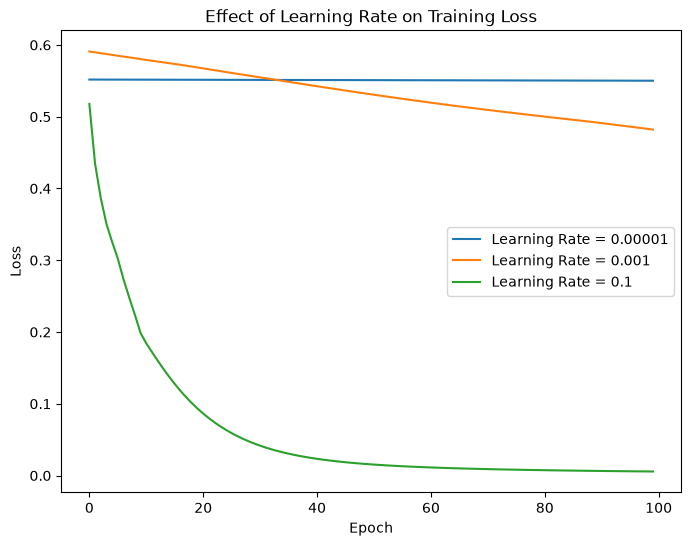

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(histories[0.00001], label="Learning Rate = 0.00001")
plt.plot(  histories[0.001], label="Learning Rate = 0.001")
plt.plot( histories[0.1], label="Learning Rate = 0.1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()

plt.show()

### Learning Rate Experiment Interpretation

The three learning rates produced different training behaviors.

A learning rate of `0.00001` was too small, as the loss remained almost constant and the model learned very slowly.

A learning rate of `0.001` allowed the model to learn gradually, with the loss decreasing steadily over the epochs.

A learning rate of `0.1` produced the fastest decrease in loss in this experiment, and the loss approached zero without showing instability.

This experiment shows that the Learning Rate strongly affects how quickly the Neural Network learns and how the loss changes during training.

## Step 3 — Explain Backpropagation

Backpropagation is the process the Neural Network uses to understand which weights caused the error.

It starts from the Loss and moves backward through the network.

The Chain Rule is used because the output depends on many connected calculations from one layer to another.

Backpropagation calculates the gradients, and the optimizer uses these gradients to update the weights and reduce the Loss.